✔ Đã nạp cấu hình tối ưu. CV_R2 XGB: 0.7621, CV_R2 LGB: 0.7820
🔥 Đang huấn luyện mô hình XGBoost Tuned...
🔥 Đang huấn luyện mô hình LightGBM Tuned...
[LightGBM] [Warning] feature_fraction is set=0.9452894614715269, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9452894614715269
[LightGBM] [Warning] bagging_fraction is set=0.7435853485550725, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7435853485550725
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.9452894614715269, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9452894614715269
[LightGBM] [Warning] bagging_fraction is set=0.7435853485550725, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7435853485550725
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Info] Auto-choosing 

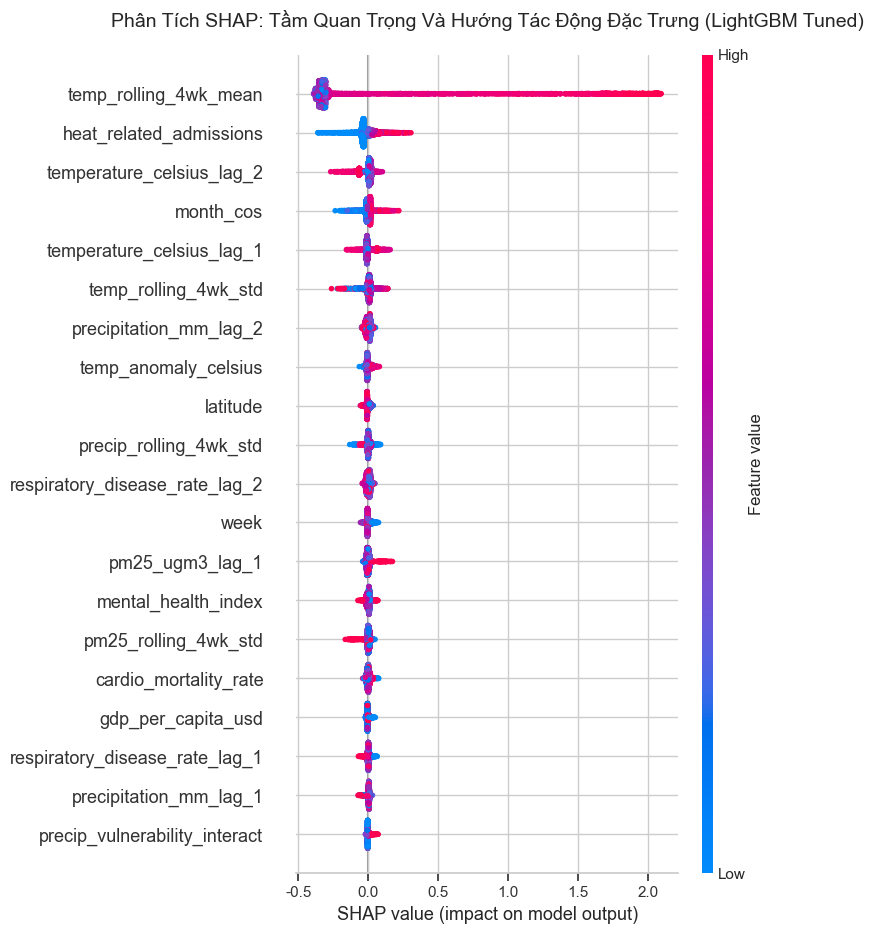

✔ Đã lưu Feature Importance.
✔ Đã lưu Model Card.

✔ Hệ thống hoàn tất! Đã đóng gói các mô hình lưu trữ tại thư mục '../artifacts/'
Training features: 38


In [1]:
# =====================================================================
# Phase 5: Final Production Training, Ensemble Blending & Global Evaluation
# =====================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import joblib
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Setting giao diện đồ thị chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

# 1. LOAD DATA VÀ CÔ LẬP MA TRẬN SỐ HỌC KHÔNG LEAKAGE
df_train = pd.read_csv('../data/processed/train_features.csv')
df_test = pd.read_csv('../data/processed/test_features.csv')

metadata_cols = ['record_id', 'date', 'country_name', 'region', 'income_level', 'vector_disease_risk_score', 'target_log']
synthetic_leakage_cols = ['temperature_celsius', 'precipitation_mm', 'pm25_ugm3']
drop_cols = metadata_cols + synthetic_leakage_cols

features = [col for col in df_train.columns if col not in drop_cols]

X_train_fit = df_train[features].select_dtypes(include=[np.number])
X_test_fit = df_test[features].select_dtypes(include=[np.number])

y_train_log = df_train['target_log']
y_test_original = df_test['vector_disease_risk_score']

# 2. NẠP CẤU HÌNH SIÊU THAM SỐ TỐI ƯU TỪ OPTUNA
with open('../metrics/best_params_xgboost.json', 'r') as f:
    xgb_data = json.load(f)
with open('../metrics/best_params_lightgbm.json', 'r') as f:
    lgb_data = json.load(f)

# Tách riêng tham số để huấn luyện và điểm số để báo cáo
best_score_xgb = xgb_data.pop('best_score')
best_score_lgb = lgb_data.pop('best_score')

best_params_xgb = xgb_data
best_params_lgb = lgb_data

print(f"✔ Đã nạp cấu hình tối ưu. CV_R2 XGB: {best_score_xgb:.4f}, CV_R2 LGB: {best_score_lgb:.4f}")

# 3. HUẤN LUYỆN SONG SONG HAI SIÊU MÔ HÌNH PRODUCTION
print("🔥 Đang huấn luyện mô hình XGBoost Tuned...")
model_xgb = xgb.XGBRegressor(**best_params_xgb, random_state=42, n_jobs=-1)
model_xgb.fit(X_train_fit, y_train_log)

print("🔥 Đang huấn luyện mô hình LightGBM Tuned...")
model_lgb = lgb.LGBMRegressor(**best_params_lgb, random_state=42, n_jobs=-1)
model_lgb.fit(X_train_fit, y_train_log)

# 4. THỰC HIỆN DỰ BÁO VÀ CHUYỂN ĐỔI NGƯỢC THANG ĐIỂM GỐC (INVERSE LOG)
preds_log_xgb = model_xgb.predict(X_test_fit)
preds_log_lgb = model_lgb.predict(X_test_fit)

# Cơ chế Blending 50/50 trên không gian log trước khi đưa về điểm gốc
preds_log_blend = 0.5 * preds_log_xgb + 0.5 * preds_log_lgb

def inverse_and_clip(preds_log):
    preds_orig = np.expm1(preds_log)
    return np.clip(preds_orig, 0, 100)

y_pred_xgb_orig = inverse_and_clip(preds_log_xgb)
y_pred_lgb_orig = inverse_and_clip(preds_log_lgb)
y_pred_blend_orig = inverse_and_clip(preds_log_blend)

# 5. HÀM TÍNH TOÁN METRIC CHUẨN XÁC
def evaluate_model(y_true, y_pred):
    return {
        "Test_MAE": round(mean_absolute_error(y_true, y_pred), 4),
        "Test_RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "Test_R2": round(r2_score(y_true, y_pred), 4)
    }

metrics_xgb = evaluate_model(y_test_original, y_pred_xgb_orig)
metrics_lgb = evaluate_model(y_test_original, y_pred_lgb_orig)
metrics_blend = evaluate_model(y_test_original, y_pred_blend_orig)

# 6. ĐỐI CHIẾU SÒNG PHẲNG VỚI CÁC BASELINE BAN ĐẦU
with open('../metrics/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

# Tính điểm CV trung bình cho Ensemble
cv_r2_blend = (best_score_xgb + best_score_lgb) / 2

# Đưa các kết quả tối ưu vào bảng tổng hợp
final_report = baseline_results.copy()
final_report["XGBoost_Optuna_Tuned"] = {"Mean_CV_R2": best_score_xgb, **metrics_xgb}
final_report["LightGBM_Optuna_Tuned"] = {"Mean_CV_R2": best_score_lgb, **metrics_lgb}
final_report["Ensemble_Blend_Champion"] = {"Mean_CV_R2": round(cv_r2_blend, 4), **metrics_blend}

df_final_report = pd.DataFrame(final_report).T

# Lọc chỉ lấy các cột cần thiết cho bảng báo cáo đẹp
cols_to_keep = ["Mean_CV_R2", "Test_MAE", "Test_RMSE", "Test_R2"]
df_final_report = df_final_report[cols_to_keep]

print("\n" + "="*25 + " BẢNG XẾP HẠNG BÁO CÁO NGHIỆM THU CUỐI CÙNG " + "="*25)
# Sắp xếp theo Test_R2 giảm dần
print(df_final_report.sort_values(by="Test_R2", ascending=False))

# 7. GIẢI THÍCH MÔ HÌNH VÔ ĐỊCH (SHAP ANALYSIS CHO CHAMPION)
print("\n🔥 Đang khởi tạo SHAP Explainer để phân tích mô hình LightGBM Tuned...")
explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer(X_test_fit)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_fit, show=False)
plt.title("Phân Tích SHAP: Tầm Quan Trọng Và Hướng Tác Động Đặc Trưng (LightGBM Tuned)", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../metrics/champion_shap_summary.png', dpi=300)
plt.show()

# 8. XUẤT CÁC MÔ HÌNH RA PRODUCTION
importance_df = pd.DataFrame({
    "feature": X_train_fit.columns,
    "importance": model_lgb.feature_importances_
})
importance_df = importance_df.sort_values(by="importance", ascending=False)
importance_df.to_csv("../metrics/feature_importance.csv", index=False)
print("✔ Đã lưu Feature Importance.")
feature_schema = {
    col: str(dtype)
    for col, dtype in X_train_fit.dtypes.items()
}

os.makedirs('../artifacts', exist_ok=True)
joblib.dump(model_xgb, '../artifacts/production_tuned_xgboost.joblib')
joblib.dump(model_lgb, '../artifacts/production_tuned_lightgbm.joblib')
# joblib.dump(list(X_train_fit.columns), '../artifacts/model_features.joblib') 
joblib.dump(
    feature_schema,
    "../artifacts/feature_schema.joblib"
)
joblib.dump(
    {
        "xgb_model": model_xgb,
        "lgb_model": model_lgb,
        "features": list(X_train_fit.columns),
        "feature_schema": feature_schema,
        "feature_count": len(X_train_fit.columns),
        "target": "vector_disease_risk_score",
        "target_transform": "log1p",
        "version": "1.0"
    },
    "../artifacts/ensemble_bundle.joblib"
)
model_card = {
    "model_name": "Climate Health Risk Predictor",
    "version": "1.0",
    "algorithm": "LightGBM + XGBoost Ensemble",
    "feature_count": len(X_train_fit.columns),
    "target": "vector_disease_risk_score",
    "test_r2": metrics_blend["Test_R2"],
    "test_mae": metrics_blend["Test_MAE"]
}

with open("../artifacts/model_card.json", "w") as f:
    json.dump(model_card, f, indent=4)
print("✔ Đã lưu Model Card.")
print("\n✔ Hệ thống hoàn tất! Đã đóng gói các mô hình lưu trữ tại thư mục '../artifacts/'")
print(
    f"Training features: {len(X_train_fit.columns)}"
)

In [7]:
print(feature_schema)


{'year': 'float64', 'month': 'float64', 'week': 'float64', 'latitude': 'float64', 'longitude': 'float64', 'population_millions': 'float64', 'temp_anomaly_celsius': 'float64', 'heat_wave_days': 'float64', 'drought_indicator': 'float64', 'flood_indicator': 'float64', 'extreme_weather_events': 'float64', 'cardio_mortality_rate': 'float64', 'heat_related_admissions': 'float64', 'healthcare_access_index': 'float64', 'gdp_per_capita_usd': 'float64', 'mental_health_index': 'float64', 'food_security_index': 'float64', 'temperature_celsius_lag_1': 'float64', 'precipitation_mm_lag_1': 'float64', 'pm25_ugm3_lag_1': 'float64', 'respiratory_disease_rate_lag_1': 'float64', 'waterborne_disease_incidents_lag_1': 'float64', 'temperature_celsius_lag_2': 'float64', 'precipitation_mm_lag_2': 'float64', 'pm25_ugm3_lag_2': 'float64', 'respiratory_disease_rate_lag_2': 'float64', 'waterborne_disease_incidents_lag_2': 'float64', 'precip_rolling_4wk_mean': 'float64', 'precip_rolling_4wk_sum': 'float64', 'precip

In [7]:
print(features)

['record_id', 'country_code', 'year', 'month', 'week', 'latitude', 'longitude', 'population_millions', 'temp_anomaly_celsius', 'heat_wave_days', 'drought_indicator', 'flood_indicator', 'extreme_weather_events', 'cardio_mortality_rate', 'heat_related_admissions', 'healthcare_access_index', 'gdp_per_capita_usd', 'mental_health_index', 'food_security_index', 'temperature_celsius_lag_1', 'precipitation_mm_lag_1', 'pm25_ugm3_lag_1', 'respiratory_disease_rate_lag_1', 'waterborne_disease_incidents_lag_1', 'temperature_celsius_lag_2', 'precipitation_mm_lag_2', 'pm25_ugm3_lag_2', 'respiratory_disease_rate_lag_2', 'waterborne_disease_incidents_lag_2', 'precip_rolling_4wk_mean', 'precip_rolling_4wk_sum', 'precip_rolling_4wk_std', 'temp_rolling_4wk_mean', 'temp_rolling_4wk_std', 'pm25_rolling_4wk_mean', 'pm25_rolling_4wk_std', 'month_sin', 'month_cos', 'income_encoded', 'precip_vulnerability_interact']
